* Robust Model Fitting 
* Straight Lines with Hough Transform 
* RANSAC 

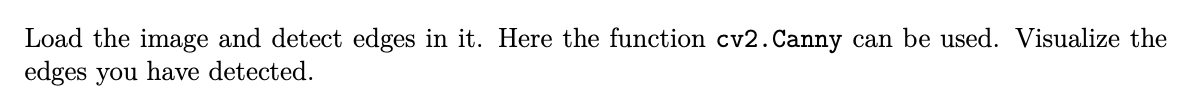

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import fixed, interact, IntSlider

# --- 1. Load the Grayscale Image Target ---
image_path = '../week6/week06_data/Box3.bmp'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not locate data frame at {image_path}")
else:
    def canny_edges(image_path, t1, t2): 
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        edges = cv2.Canny(img, threshold1= t1, threshold2=t2)
        plt.figure(figsize=(8, 6))
        plt.imshow(edges, cmap='gray')
        plt.title(f'Canny Edges (t1={t1}, t2={t2})')
        plt.axis('off')
        plt.show()

    interact(canny_edges, image_path=fixed(image_path), t1=IntSlider(min=0, max=255, step=1, value=100), t2=IntSlider(min=0, max=255, step=1, value=200))

interactive(children=(IntSlider(value=100, description='t1', max=255), IntSlider(value=200, description='t2', …

# 7.2 

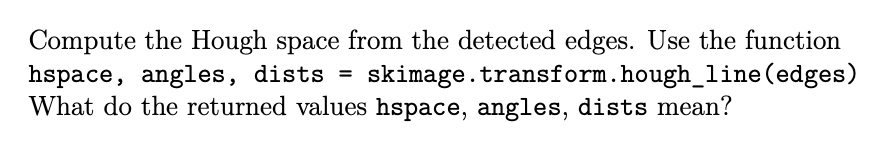

In [10]:
import skimage.transform

hspace, angles, dists = skimage.transform.hough_line(edges)

print (f"hspace shape: {hspace.shape}, angles shape: {angles.shape}, dists shape: {dists.shape}")

hspace shape: (1601, 180), angles shape: (180,), dists shape: (1601,)


hspace : 
* (The Accumulator Matrix): A 2D histogram matrix where the axes correspond to your angles indices and dists values.
    * Every white edge pixel in your image votes for all possible combinations of lines that could cross through it, mapping out a sinusoidal curve in the parameter space.
    * Where these sinusoidal waves cross and cluster together into a bright peak point, it indicates that a high number of edge pixels align perfectly along that specific geometric trajectory. A peak in Hough space means a straight line exists in image space!
* Every single coordinate cell hspace[d, a] inside this 1601×180 grid counts how many white edge pixels from your Canny mask align perfectly with that specific (ρ,θ) trajectory.

dists (p): 
* A 1D array representing the shortest perpendicular distance (in pixels) from the top-left image origin (0,0) to the target straight line.
* Its length of 1601 entries represents the maximum pixel travel range (ρ) across the image.

angles ($theta$): 
* A 1D array representing the angular orientation of the normal vector pointing from the image origin (0,0) to the closest point on the line. By default, skimage sets this range from $-(2/π) to + π/2 radians $ $(−90∘ to +90 ∘) $.
* In this example: Its length of 180 elements means scikit-image sliced the search area into exactly 180 discrete angular increments.



In [11]:
from skimage.transform import hough_line_peaks

# Extract the most dominant structural lines from your accumulator space
# num_peaks=4 isolates the primary four bounding walls of your box target
num_peaks_to_find = 4
accum_votes, peak_angles, peak_dists = hough_line_peaks(
    hspace, angles, dists, num_peaks=num_peaks_to_find
)

print(f"=================== LINE SEARCH RESULTS FOR BOX3.BMP ===================")
for i in range(len(accum_votes)):
    angle_deg = np.rad2deg(peak_angles[i])
    print(f"Line #{i+1}: Perpendicular Distance (ρ) = {peak_dists[i]:.1f} pixels, Orientation (θ) = {angle_deg:.1f}° (Votes: {accum_votes[i]})")

=================== LINE SEARCH RESULTS FOR BOX3.BMP ===================
Line #1: Perpendicular Distance (ρ) = 495.0 pixels, Orientation (θ) = 49.0° (Votes: 163)
Line #2: Perpendicular Distance (ρ) = 180.0 pixels, Orientation (θ) = 60.0° (Votes: 158)
Line #3: Perpendicular Distance (ρ) = -17.0 pixels, Orientation (θ) = -31.0° (Votes: 155)
Line #4: Perpendicular Distance (ρ) = 117.0 pixels, Orientation (θ) = -53.0° (Votes: 151)


# 7.3 

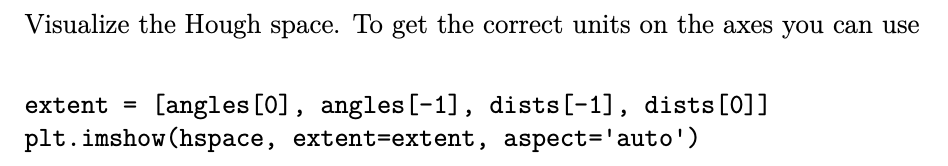

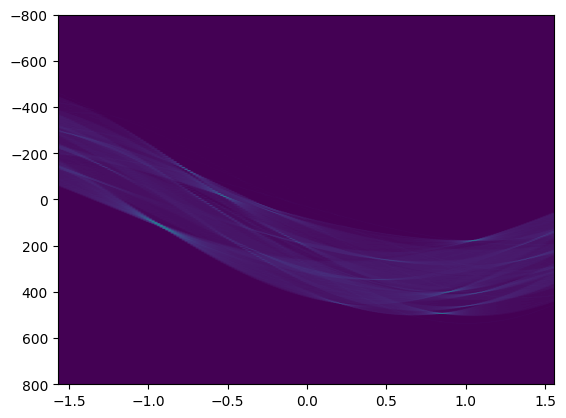

In [12]:
extent = [angles[0], angles[-1], dists[-1], dists[0]]
plt.imshow(hspace, extent=extent, aspect='auto')

# 7.4

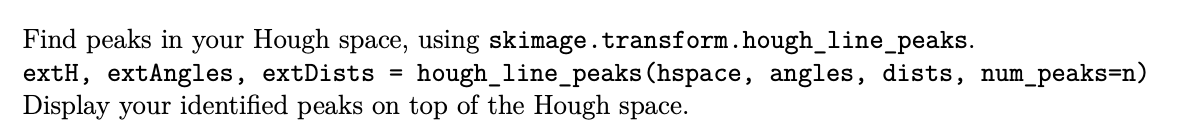

=================== 7.4 EXTRACTED HOUGH PEAKS ===================
Peak #1: Accumulator Votes = 163, 	Angle = 49.0°, 	Distance = 495.0 px
Peak #2: Accumulator Votes = 158, 	Angle = 60.0°, 	Distance = 180.0 px
Peak #3: Accumulator Votes = 155, 	Angle = -31.0°, 	Distance = -17.0 px
Peak #4: Accumulator Votes = 151, 	Angle = -53.0°, 	Distance = 117.0 px
Peak #5: Accumulator Votes = 141, 	Angle = 52.0°, 	Distance = 400.0 px
Peak #6: Accumulator Votes = 135, 	Angle = -44.0°, 	Distance = -129.0 px


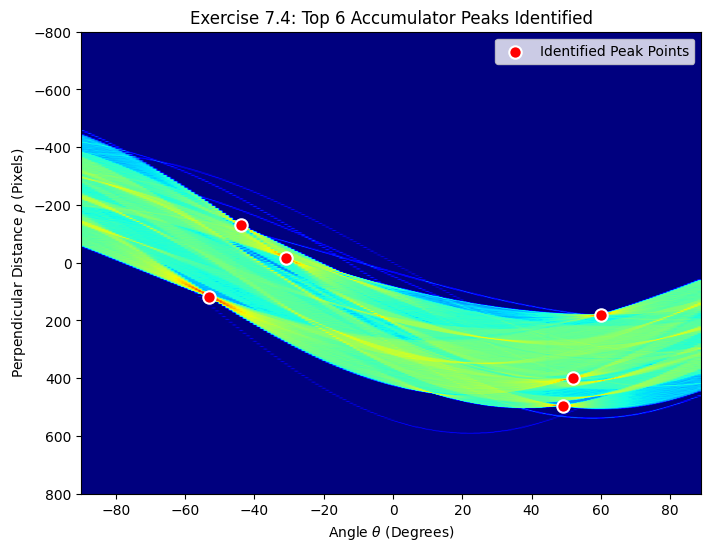

In [30]:
skimage.transform.hough_line_peaks

# n=4, rectangular structure defined by four primary linear edge boundaries
n_cube = 6 # to cath all 3 visible face of a 3D box 
extH, extAngles, extDists = hough_line_peaks(hspace, angles, dists, num_peaks=n_cube)

img_color = cv2.imread(image_path)
img_overlay = img_color.copy()

print("=================== 7.4 EXTRACTED HOUGH PEAKS ===================")
for i in range(len(extH)):
    print(f"Peak #{i+1}: Accumulator Votes = {extH[i]}, \tAngle = {np.rad2deg(extAngles[i]):.1f}°, \tDistance = {extDists[i]:.1f} px")

# Generate the parameter map visualization
plt.figure(figsize=(8, 6))

# Plot the 2D voting background (using log1p so faint lines remain visible)
plt.imshow(np.log1p(hspace), cmap='jet', 
           extent=[np.rad2deg(angles[0]), np.rad2deg(angles[-1]), dists[-1], dists[0]], 
           aspect='auto')

# Overlay the peak locations as distinct red circles matching the prompt criteria
plt.scatter(np.rad2deg(extAngles), extDists, color='red', marker='o', s=80, edgecolors='white', linewidths=1.5, label='Identified Peak Points')

plt.title(f"Exercise 7.4: Top {n_cube} Accumulator Peaks Identified")
plt.xlabel("Angle $\\theta$ (Degrees)")
plt.ylabel("Perpendicular Distance $\\rho$ (Pixels)")
plt.legend(loc='upper right')
plt.axis('on')
plt.show()

# 7.5 

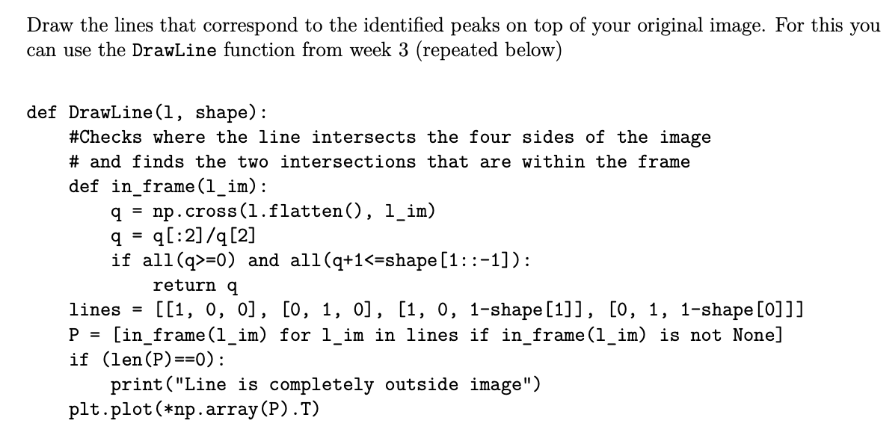

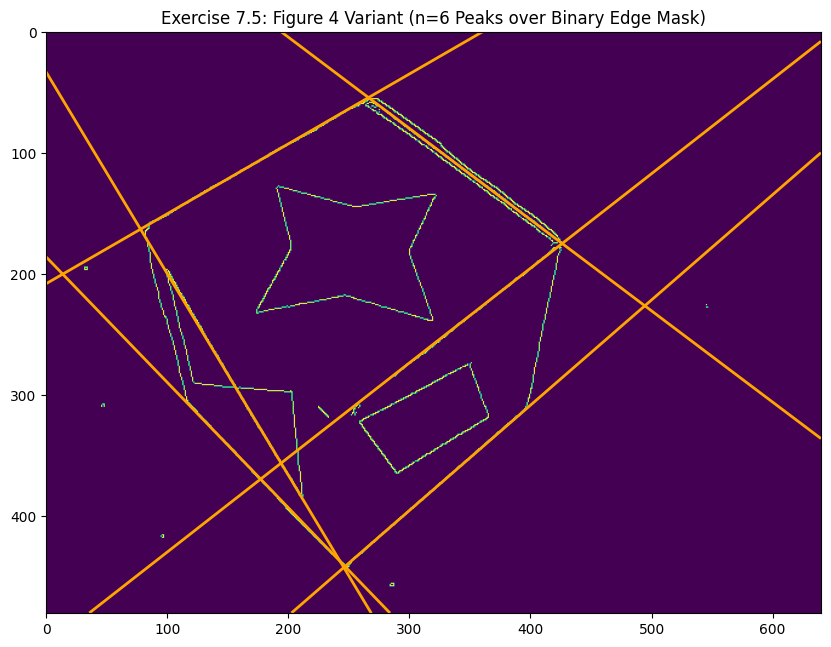

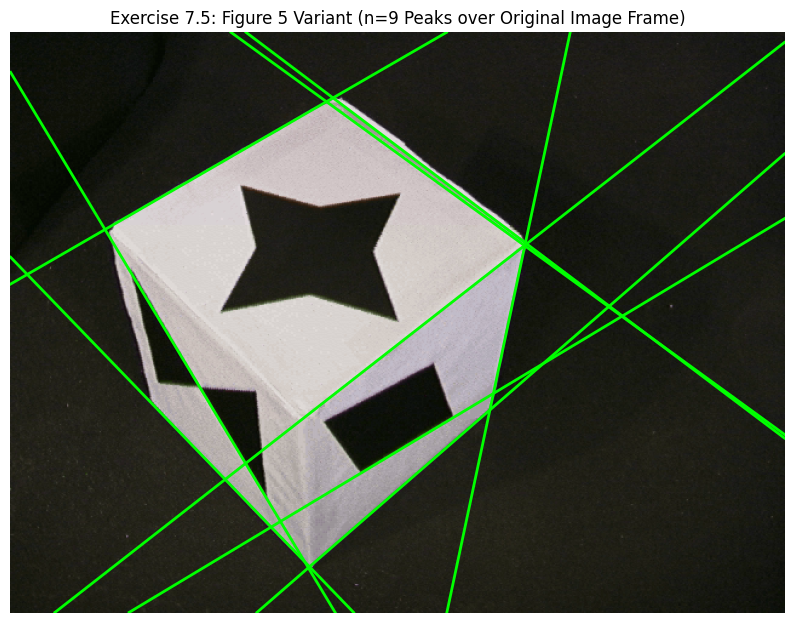

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import hough_line_peaks

# ==============================================================================
# 1. SETUP BASE ASSETS & IMAGES
# ==============================================================================
image_path = '../week6/week06_data/Box3.bmp'
img_raw = cv2.imread(image_path)
h_img, w_img = img_raw.shape[:2]

# Ensure you are referencing your existing 'hspace', 'angles', 'dists', and 'edges' arrays
# from your previous cell run.

# ==============================================================================
# 2. HELPER TO CONVERT POLAR PEAKS TO HOMOGENOUS LINES
# ==============================================================================
def get_homogenous_lines(num_peaks):
    """Extracts the top requested peaks and converts them to [a, b, c] line vectors."""
    extH, extAngles, extDists = hough_line_peaks(hspace, angles, dists, num_peaks=num_peaks)
    lines_list = []
    for distance, angle in zip(extDists, extAngles):
        a = np.cos(angle)
        b = np.sin(angle)
        c = -distance
        lines_list.append(np.array([a, b, c]))
    return lines_list

# ==============================================================================
# 3. PROFESSOR'S PROVIDED DRAWLINE FUNCTION (MODIFIED SLIGHTLY FOR SPECIFIC PLOTS)
# ==============================================================================
def DrawLineOnPlot(l, shape, color_str):
    """
    Finds line intersection clips against image boundaries and plots using matplotlib.
    """
    def in_frame(l_im):
        q = np.cross(l.flatten(), l_im)
        if q[2] == 0: 
            return None
        q = q[:2] / q[2]
        if all(q >= 0) and all(q + 1 <= shape[1::-1]):
            return q
        return None

    border_lines = [[1, 0, 0], [0, 1, 0], [1, 0, 1 - shape[1]], [0, 1, 1 - shape[0]]]
    P = [in_frame(l_im) for l_im in border_lines if in_frame(l_im) is not None]
    
    if len(P) > 0:
        pts = np.array(P)
        plt.plot(pts[:, 0], pts[:, 1], color=color_str, linewidth=2)

# ==============================================================================
# 4. RENDERING VARIANT 1: FIGURE 4 (n=6 Over the Edge Mask)
# ==============================================================================
plt.figure(figsize=(10, 8))
# Use viridis or gray to match the dark edge matrix backdrop
plt.imshow(edges, cmap='viridis') 

lines_6 = get_homogenous_lines(num_peaks=6)
for l in lines_6:
    # Drawing lines using a bright contrast color (like red or orange)
    DrawLineOnPlot(l, (h_img, w_img), 'orange')

plt.title("Exercise 7.5: Figure 4 Variant (n=6 Peaks over Binary Edge Mask)")
plt.xlim(0, w_img)
plt.ylim(h_img, 0) # Maintain uniform standard pixel indexing orientation
plt.axis('on')
plt.show()

# ==============================================================================
# 5. RENDERING VARIANT 2: FIGURE 5 (n=9 Over the Original Image Frame)
# ==============================================================================
plt.figure(figsize=(10, 8))
# Swap the backdrop matrix out for your actual photographic frame
plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))

lines_9 = get_homogenous_lines(num_peaks=9)
for l in lines_9:
    # Drawing lines using neon green matching Figure 5
    DrawLineOnPlot(l, (h_img, w_img), 'lime')

plt.title("Exercise 7.5: Figure 5 Variant (n=9 Peaks over Original Image Frame)")
plt.axis('off')
plt.show()

# 7.6 (RANSAC )

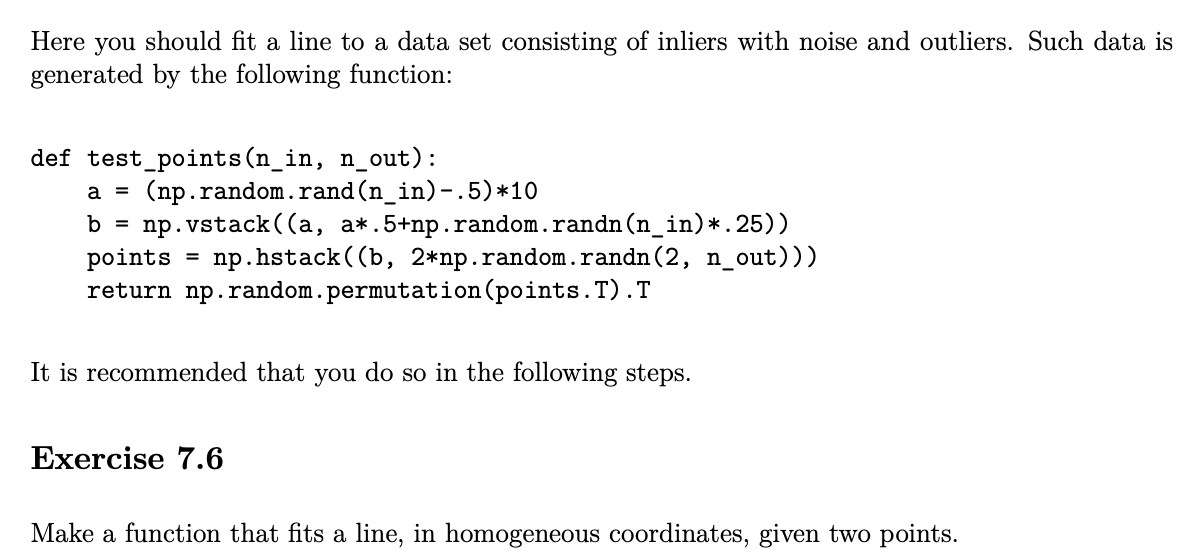

In [33]:
def test_points(n_in, n_out):
    a = (np.random.rand(n_in)-.5)*10
    b = np.vstack((a, a*.5+np.random.randn(n_in)*.25))
    points = np.hstack((b, 2*np.random.randn(2, n_out)))
    return np.random.permutation(points.T).T

In [34]:
def fit_line_2points(p1, p2): 
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)

    if p1.size == 2: 
        p1 = np.append(p1, 1)
    if p2.size == 2: 
        p2 = np.append(p2, 1)

    l = np.cross(p1, p2)
    norm = np.linalg.norm(l[:2])
    if norm != 0:
        l = l / norm
    return l

In [35]:
# Define two easy points: (0, 5) and (10, 5). 
# A straight line crossing these should be a perfectly horizontal line at y = 5.
# Matrix equation form: 0*x + 1*y - 5 = 0  ->  l = [0, 1, -5]
point_A = [0.0, 5.0]
point_B = [10.0, 5.0]

calculated_line = fit_line_2points(point_A, point_B)

print("=================== 7.6 FITTING VERIFICATION ===================")
print(f"Point A: {point_A}")
print(f"Point B: {point_B}")
print(f"Resulting Homogeneous Line Vector (l): {calculated_line}")
print(f"Line equation: {calculated_line[0]:.1f}x + {calculated_line[1]:.1f}y + ({calculated_line[2]:.1f}) = 0")

=================== 7.6 FITTING VERIFICATION ===================
Point A: [0.0, 5.0]
Point B: [10.0, 5.0]
Resulting Homogeneous Line Vector (l): [ 0.  1. -5.]
Line equation: 0.0x + 1.0y + (-5.0) = 0
